## Priority Queue ADT with Update Ability

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from heapq import heappush, heappop

push( (priority (float), obj) )

pop() -> obj at the front of the line

(New!!)
update( (priority (float), obj) )


We want to implement a method update that can update the priority of a particular object in $O(\log(N))$ time.

To do this, we use a dictionary <code>_obj2idx</code> to quickly locate an object in the heap

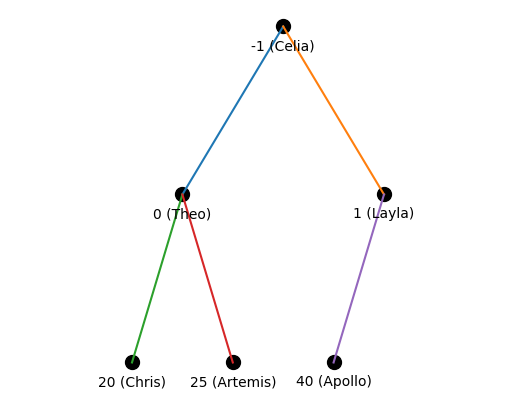

In [11]:
class HeapTree(object):
    def __init__(self):
        self._arr = []
        self._obj2idx = {} # Key: obj (hashable), Value: Index into _arr where we can find obj

    def __contains__(self, obj):
        return obj in self._obj2idx
    
    def __len__(self):
        return len(self._arr)

    def _children(self, i):
        """
        Parameters
        ----------
        i: int
            Index of a node

        Returns
        -------
        list of indices of children of that node
        """
        children = []
        if 2*i + 1 < len(self._arr):
            children.append(2*i + 1)
        if 2*i + 2 < len(self._arr):
            children.append(2*i + 2)
        return children
    
    def _parent(self, i):
        return (i-1)//2
    
    def _swap(self, i, j):
        obji = self._arr[i][1]
        objj = self._arr[j][1]
        self._obj2idx[obji] = j
        self._obj2idx[objj] = i
        self._arr[i], self._arr[j] = self._arr[j], self._arr[i]
        
    
    def _heapup(self, i):
        """
        Keep bubbling the node at i up until it 
        satisfies the heap condition
        """
        if i > 0:
            parent = self._parent(i)
            if self._arr[i][0] < self._arr[parent][0]:
                self._swap(i, parent)
                self._heapup(parent)
                
    def _heapdown(self, i):
        children = self._children(i)
        if len(children) > 0:
            ## Make child be the smaller of the two children
            child = children[0]
            if len(children) > 1:
                if self._arr[children[1]][0] < self._arr[children[0]][0]:
                    child = children[1]
            if self._arr[child][0] < self._arr[i][0]:
                self._swap(i, child)
                self._heapdown(child)
        
    def push(self, entry):
        """
        Parameters
        ----------
        entry: (priority, obj)
        """
        ## Step 1: Put this entry at the end of the _arr
        self._arr.append(entry)
        self._obj2idx[entry[1]] = len(self._arr)-1

        ## Step 2: Bubble up entry until the heap condition is satisfied
        self._heapup(len(self._arr)-1)
    
    def pop(self):
        assert(len(self._arr) > 0)
        ret = self._arr[0][1]
        ## Move the last element to the root
        self._arr[0] = self._arr[-1]
        ## Take off the last element
        self._arr.pop()
        ## Fix up the internal structure
        self._heapdown(0)
        return ret

    def update(self, entry):
        """
        Parameters
        ----------
        entry: (priority, obj)
        """
        (new_priority, obj) = entry
        assert(obj in self)
        idx = self._obj2idx[obj]
        old_priority = self._arr[idx][0]
        self._arr[idx] = (new_priority, obj)
        if new_priority < old_priority:
            self._heapup(idx)
        elif new_priority > old_priority:
            self._heapdown(idx)
            
        
    
    def draw(self, fac=1.5):
        N = len(self._arr)
        height = int(np.ceil(np.log2(N)))
        width = 2**height
        xs = np.zeros(N)
        ys = np.zeros(N)
        level = -1
        xi = 0
        # First draw nodes, and remember positions
        # in the process
        x0 = width/2
        for i in range(N):
            if np.log2(i+1) == int(np.log2(i+1)):
                level += 1
                xi = 0
                x0 -= fac*2**(height-level-1)
            stride = fac*2**(height-level)
            x = x0 + xi*stride
            y = -5*level
            plt.scatter([x], [y], 100, c='k')
            s = "{}".format(self._arr[i][0])
            if self._arr[i][1]:
                s = s + " ({})".format(self._arr[i][1])
            plt.text(x, y-0.7, s, horizontalalignment='center')
            xs[i] = x
            ys[i] = y
            xi += 1
        # Next draw edges
        for i in range(N):
            for j in self._children(i):
                plt.plot([xs[i], xs[j]], [ys[i], ys[j]])
        plt.axis("off")
        plt.axis("equal")


T = HeapTree()
T.push((10, "Theo"))
T.push((20, "Chris"))
T.push((5, "Celia"))
T.push((1, "Layla"))
T.push((2, "Artemis"))
T.push((3, "Apollo"))
T.update((0, "Theo"))
T.update((25, "Artemis"))
T.update((40, "Apollo"))
T.update((-1, "Celia"))
T.draw()